In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.metrics import confusion_matrix

KNN classification on IRIS dataset

In [3]:
iris = load_iris()

print('iris data shape: ', iris.data.shape)
print('iris data features: ', iris.feature_names)
print('Iris data examples: ', iris.data[:3])
print('iris labels: ', iris.target)

iris data shape:  (150, 4)
iris data features:  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Iris data examples:  [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]
iris labels:  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [4]:
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['target'] = pd.Series(iris.target)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
print('value counts of iris dataset')
iris_df['target'].value_counts()

value counts of iris dataset


target
0    50
1    50
2    50
Name: count, dtype: int64

In [6]:
print('values of iris dataset')
iris_df.values[:3]

values of iris dataset


array([[5.1, 3.5, 1.4, 0.2, 0. ],
       [4.9, 3. , 1.4, 0.2, 0. ],
       [4.7, 3.2, 1.3, 0.2, 0. ]])

In [7]:
X = iris_df.iloc[:,:4]
y = iris_df.iloc[:,-1]

print(X[:3])

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2


In [8]:
def iris_knn(X,y,k,newdata):
    X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3)
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train, y_train)
    y_pred_train = knn.predict(X_train)
    y_pred_test  = knn.predict(X_test)
    
    y_pred_unknown = knn.predict(newdata)
    
    scores_train = metrics.accuracy_score(y_train,y_pred_train)
    scores_test  = metrics.accuracy_score(y_test,y_pred_test)
    
    return scores_train, scores_test, y_test, y_pred_test, y_pred_unknown

X_unknown = [[4,2,1.3,0.4],
       [4,3,3.2,2.2]]

k = 3
scores_train, scores_test, y_test, pred_test, pred_unknown = iris_knn(X,y,k,X_unknown)

print('n_neighbors가 {0:d}일 때 학습 정확도: {1:.3f}'.format(k,scores_train))
print('n_neighbors가 {0:d}일 때 검증 정확도: {1:.3f}'.format(k,scores_test))

n_neighbors가 3일 때 학습 정확도: 0.981
n_neighbors가 3일 때 검증 정확도: 0.956


/opt/conda/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [9]:
classes = {0:'setosa', 1:'versicolor', 2:'virginica'}
for i in range(len(X_unknown)):
    print('{} 특성을 가지는 품종: {}'.format(X_unknown[i], classes[pred_unknown[i]]))

[4, 2, 1.3, 0.4] 특성을 가지는 품종: setosa
[4, 3, 3.2, 2.2] 특성을 가지는 품종: versicolor


In [10]:
cm = confusion_matrix(y_test,pred_test)
print(cm)

[[19  0  0]
 [ 0 15  2]
 [ 0  0  9]]


<Axes: >

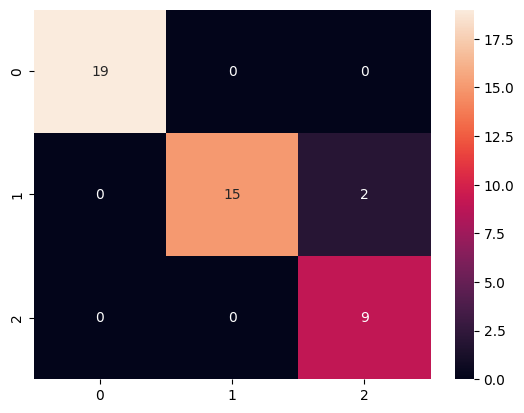

In [11]:
sns.heatmap(cm,annot = True)

SVM on IRIS

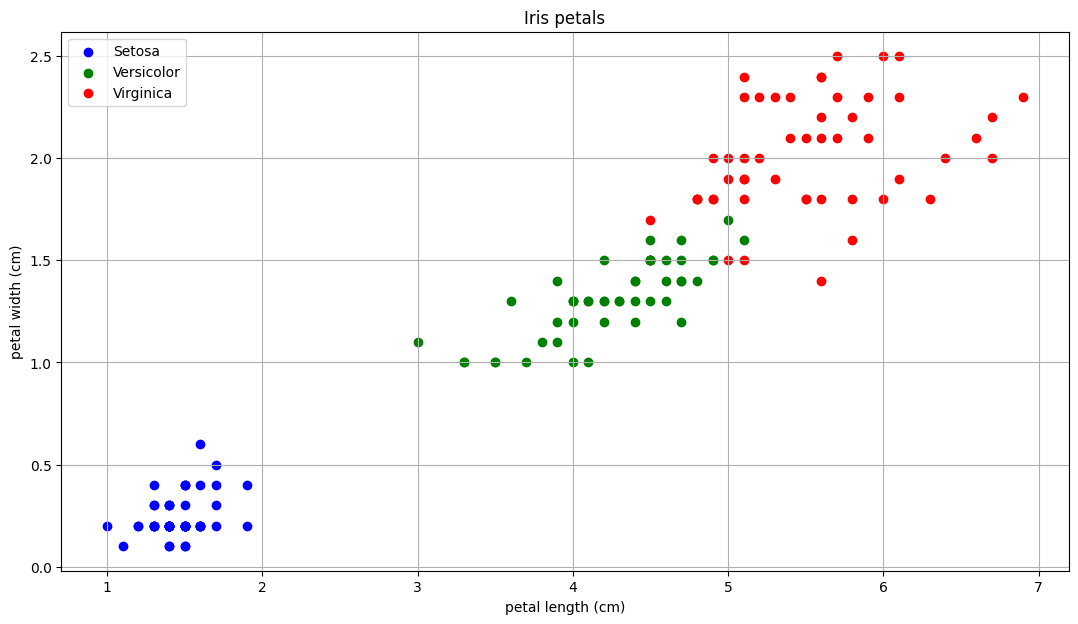

In [12]:
setosa = iris_df[iris_df['target'] == 0]
versicolor = iris_df[iris_df['target'] == 1]
virginica = iris_df[iris_df['target'] == 2]

fig, ax = plt.subplots()
fig.set_size_inches(13, 7) # adjusting the length and width of plot

# lables and scatter points
ax.scatter(setosa['petal length (cm)'], setosa['petal width (cm)'], label="Setosa", facecolor="blue")
ax.scatter(versicolor['petal length (cm)'], versicolor['petal width (cm)'], label="Versicolor", facecolor="green")
ax.scatter(virginica['petal length (cm)'], virginica['petal width (cm)'], label="Virginica", facecolor="red")

ax.set_xlabel("petal length (cm)")
ax.set_ylabel("petal width (cm)")
ax.grid()
ax.set_title("Iris petals")
ax.legend()

In [13]:
X = iris_df.iloc[:,2:4]
#y is the same

#scaling X variables
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

In [14]:
from sklearn.svm import LinearSVC

svm = LinearSVC(C=1,loss='hinge')
svm.fit(X_train,y_train)

LinearSVC(C=1, loss='hinge')

In [15]:
print(svm.coef_)
print(svm.intercept_)

w=svm.coef_
b=svm.intercept_

[[-1.18156242 -1.17175057]
 [ 1.99536579 -1.68569907]
 [ 1.42884443  2.41037835]]
[-1.48071688 -0.65661252 -2.32052569]


In [16]:
from sklearn.metrics import accuracy_score

pred = svm.predict(X_test)
print("Accuracy :", accuracy_score(pred, y_test))

Accuracy : 0.9333333333333333


<Axes: >

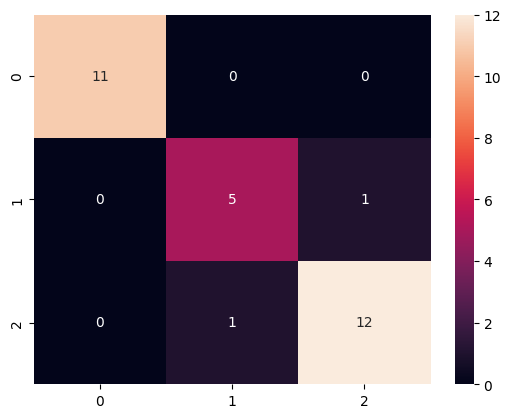

In [17]:
cm = confusion_matrix(y_test,pred)
sns.heatmap(cm,annot = True)

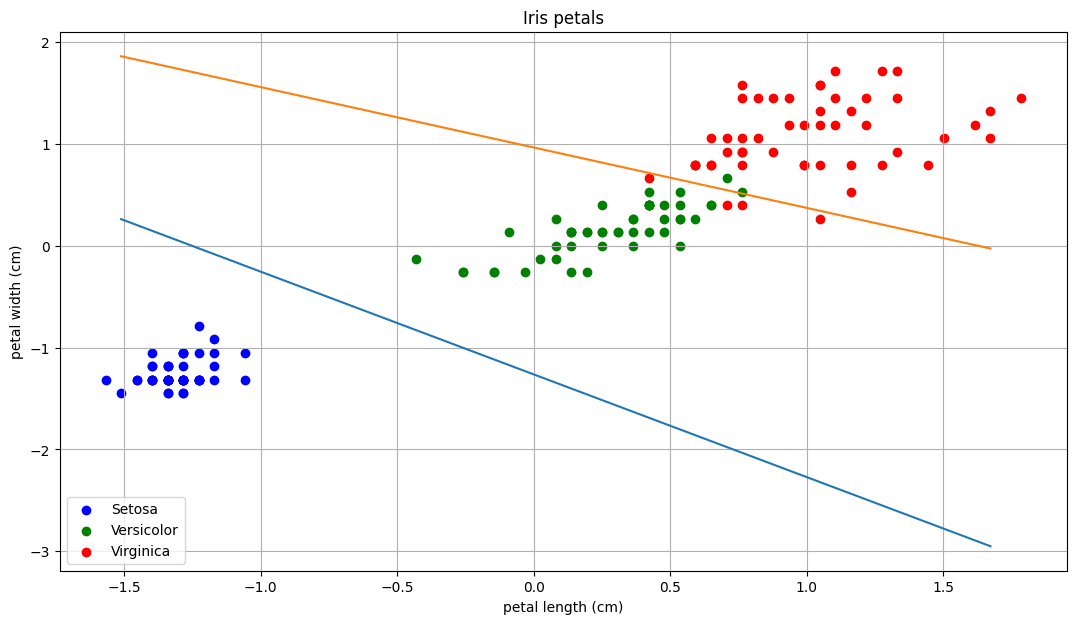

In [18]:
setosa = X_scaled[y == 0]
versicolor = X_scaled[y == 1]
virginica = X_scaled[y == 2]

fig, ax = plt.subplots()
fig.set_size_inches(13, 7) # adjusting the length and width of plot

# lables and scatter points
ax.scatter(setosa[:,0], setosa[:,1], label="Setosa", facecolor="blue")
ax.scatter(versicolor[:,0], versicolor[:,1], label="Versicolor", facecolor="green")
ax.scatter(virginica[:,0], virginica[:,1], label="Virginica", facecolor="red")

ax.set_xlabel("petal length (cm)")
ax.set_ylabel("petal width (cm)")
ax.grid()
ax.set_title("Iris petals")
ax.legend()

####################################################################

x_ =np.linspace(np.min(X_test[:,0]),np.max(X_test[:,0]))
y_ = -(w[0,0]/w[0,1])*x_ - b[0]/w[0,1]
ax.plot(x_,y_)
y_ = -(w[2,0]/w[2,1])*x_ - b[2]/w[2,1]
ax.plot(x_,y_)

Decision Tree

In [19]:
from sklearn.tree import DecisionTreeClassifier  
clf_gini = DecisionTreeClassifier(criterion = "gini",                # Criterion
                                  max_depth = 5,                     # Max Height of Tree
                                  min_samples_leaf = 3,              # Maximum Leaf samples
                                  random_state = 100)
clf_gini.fit(X_train, y_train)  

DecisionTreeClassifier(max_depth=5, min_samples_leaf=3, random_state=100)

In [20]:
clf_entropy = DecisionTreeClassifier(criterion = "entropy",          # Criterion
                                     max_depth = 5,                  # Max Height of Tree
                                     min_samples_leaf = 3,           # Max Leaf samples
                                     random_state = 100)
clf_entropy.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=3,
                       random_state=100)

In [21]:
from sklearn.metrics import accuracy_score                          # For calculating accuracy
from sklearn.metrics import classification_report                   # For evaluating the model

y_pred_gini = clf_gini.predict(X_test)                                # Performing Prediction on test input
print ("Accuracy : ", accuracy_score(y_test,y_pred_gini)*100)         # Evaulating predictions with test labels
print ("Report : ",  classification_report(y_test, y_pred_gini))

Accuracy :  93.33333333333333
Report :                precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.83      0.83      0.83         6
           2       0.92      0.92      0.92        13

    accuracy                           0.93        30
   macro avg       0.92      0.92      0.92        30
weighted avg       0.93      0.93      0.93        30



In [22]:
y_pred_entropy = clf_entropy.predict(X_test)                                # Performing Prediction on test input
print ("Accuracy : ", accuracy_score(y_test,y_pred_entropy)*100)            # Evaulating predictions with test labels
print ("Report : ",  classification_report(y_test, y_pred_entropy))

Accuracy :  93.33333333333333
Report :                precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.83      0.83      0.83         6
           2       0.92      0.92      0.92        13

    accuracy                           0.93        30
   macro avg       0.92      0.92      0.92        30
weighted avg       0.93      0.93      0.93        30



[Text(0.375, 0.875, 'x[0] <= -0.743\ngini = 0.665\nsamples = 120\nvalue = [39, 44, 37]'),
 Text(0.25, 0.625, 'gini = 0.0\nsamples = 39\nvalue = [39, 0, 0]'),
 Text(0.5, 0.625, 'x[1] <= 0.593\ngini = 0.496\nsamples = 81\nvalue = [0, 44, 37]'),
 Text(0.25, 0.375, 'x[0] <= 0.706\ngini = 0.122\nsamples = 46\nvalue = [0, 43, 3]'),
 Text(0.125, 0.125, 'gini = 0.0\nsamples = 42\nvalue = [0, 42, 0]'),
 Text(0.375, 0.125, 'gini = 0.375\nsamples = 4\nvalue = [0, 1, 3]'),
 Text(0.75, 0.375, 'x[0] <= 0.621\ngini = 0.056\nsamples = 35\nvalue = [0, 1, 34]'),
 Text(0.625, 0.125, 'gini = 0.444\nsamples = 3\nvalue = [0, 1, 2]'),
 Text(0.875, 0.125, 'gini = 0.0\nsamples = 32\nvalue = [0, 0, 32]')]

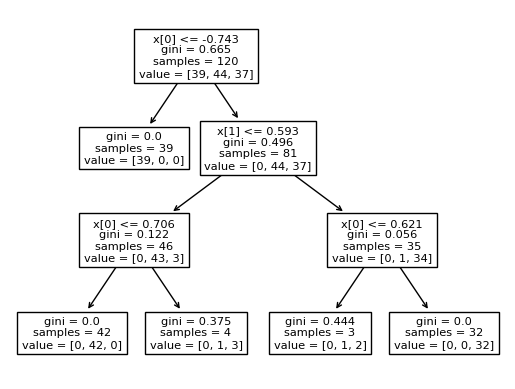

In [23]:
from sklearn import tree                                            # Visualizing Decision Tree
tree.plot_tree(clf_gini)

[Text(0.375, 0.875, 'x[0] <= -0.743\nentropy = 1.581\nsamples = 120\nvalue = [39, 44, 37]'),
 Text(0.25, 0.625, 'entropy = 0.0\nsamples = 39\nvalue = [39, 0, 0]'),
 Text(0.5, 0.625, 'x[1] <= 0.593\nentropy = 0.995\nsamples = 81\nvalue = [0, 44, 37]'),
 Text(0.25, 0.375, 'x[0] <= 0.706\nentropy = 0.348\nsamples = 46\nvalue = [0, 43, 3]'),
 Text(0.125, 0.125, 'entropy = 0.0\nsamples = 42\nvalue = [0, 42, 0]'),
 Text(0.375, 0.125, 'entropy = 0.811\nsamples = 4\nvalue = [0, 1, 3]'),
 Text(0.75, 0.375, 'x[0] <= 0.621\nentropy = 0.187\nsamples = 35\nvalue = [0, 1, 34]'),
 Text(0.625, 0.125, 'entropy = 0.918\nsamples = 3\nvalue = [0, 1, 2]'),
 Text(0.875, 0.125, 'entropy = 0.0\nsamples = 32\nvalue = [0, 0, 32]')]

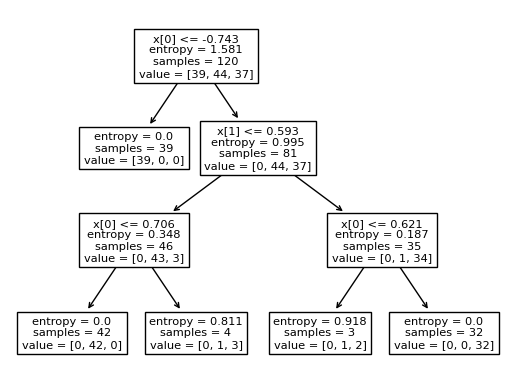

In [24]:
tree.plot_tree(clf_entropy)

In [26]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the RandomForestClassifier
# n_estimators is the number of trees in the forest, and max_depth is an optional parameter that specifies the maximum depth of each tree
clf_random_forest = RandomForestClassifier(n_estimators=10, max_depth=5, random_state=42)

# Train the RandomForestClassifier on the scaled training data
clf_random_forest.fit(X_train, y_train)

y_pred_rf = clf_random_forest.predict(X_test)                                # Performing Prediction on test input
print ("Accuracy : ", accuracy_score(y_test,y_pred_rf)*100)            # Evaulating predictions with test labels
print ("Report : ",  classification_report(y_test, y_pred_rf))

Accuracy :  93.33333333333333
Report :                precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.83      0.83      0.83         6
           2       0.92      0.92      0.92        13

    accuracy                           0.93        30
   macro avg       0.92      0.92      0.92        30
weighted avg       0.93      0.93      0.93        30



In [28]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Create AdaBoost model
ada = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=5),
    n_estimators=10,
    learning_rate=1,
    random_state=42
)

# Train the model
ada.fit(X_train, y_train)

# Predict the test set
predictions = ada.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy: {accuracy}')

Accuracy: 0.9333333333333333
